<a href="https://colab.research.google.com/github/FRJackson/MBS-first_vs1/blob/main/5243%E7%AC%AC%E4%B8%80%E6%AC%A1%E8%B4%B7%E6%AC%BE%E5%8C%85%E5%9F%BA%E6%9C%AC%E9%A2%84%E6%B5%8B%E5%88%86%E6%9E%90_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('hello waord')

hello waord


In [ ]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import statsmodels.api as sm
# import statsmodels.formula.api as smf
# import statsmodels.stats.api as sms
# import statsmodels.stats.proportion as ssp
# import statsmodels.stats.multitest as smm
# import statsmodels.stats.weightstats as ssw
# import statsmodels.stats.diagnostic as ssd

In [ ]:
import pandas as pd

# Load the dataset to analyze headers and initial structure
file_path = 'LoanPoolDataset_Detailed.csv'
data = pd.read_csv(file_path)

# Displaying headers and basic information
data_info = {
    "Column Names": data.columns.tolist(),
    "Data Types": data.dtypes.tolist(),
    "Missing Values": data.isnull().sum().tolist()
}

data_info_df = pd.DataFrame(data_info)


data_info_df


,Column Names,Data Types,Missing Values
0,Original Interest Rate_mean,float64,0
1,Original Interest Rate_q25,float64,0
2,Original Interest Rate_q75,float64,0
3,Original Interest Rate_min,float64,0
4,Original Interest Rate_max,float64,0
...,...,...,...
96,Month,object,0
97,Deal_Type,object,0
98,Deal_Number,object,0
99,Group,object,36


In [ ]:
cleaned_data = data.dropna(axis=1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# 先删除 'Pool' 列
data_no_pool = cleaned_data.drop(columns=['Pool'])

# 提取对象类型的列名用于编码
object_cols_no_pool = data_no_pool.select_dtypes(include=['object']).columns.tolist()

# 执行One-Hot编码
encoder_no_pool = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features_no_pool = encoder_no_pool.fit_transform(data_no_pool[object_cols_no_pool])

# 获取编码后的特征名称
encoded_feature_names_no_pool = encoder_no_pool.get_feature_names_out(object_cols_no_pool)

# 检查形状是否一致
print("Encoded features shape:", encoded_features_no_pool.shape)
print("Encoded feature names count:", len(encoded_feature_names_no_pool))

# 构建DataFrame
encoded_df_no_pool = pd.DataFrame(encoded_features_no_pool, columns=encoded_feature_names_no_pool)

# 与数值型数据合并
numeric_data_no_pool = data_no_pool.drop(columns=object_cols_no_pool).reset_index(drop=True)

# 确保行数一致
print("Numeric data shape:", numeric_data_no_pool.shape)
print("Encoded data shape:", encoded_df_no_pool.shape)

final_encoded_data_no_pool = pd.concat([numeric_data_no_pool, encoded_df_no_pool], axis=1)

final_encoded_data_no_pool.head()



Encoded features shape: (2326, 51)
Encoded feature names count: 51
Numeric data shape: (2326, 86)
Encoded data shape: (2326, 51)


,Original Interest Rate_mean,Original Interest Rate_q25,Original Interest Rate_q75,Original Interest Rate_min,Original Interest Rate_max,Current Interest Rate_mean,Current Interest Rate_q25,Current Interest Rate_q75,Current Interest Rate_min,Current Interest Rate_max,...,Deal_Number_02,Deal_Number_03,Deal_Number_04,Deal_Number_05,Deal_Number_06,Deal_Number_07,Deal_Number_08,Deal_Number_09,Deal_Number_1,Deal_Number_BT1
0,3.886249,3.625,4.0,2.75,6.375,3.860407,3.625,4.0,2.75,6.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.886249,3.625,4.0,2.75,6.375,3.855684,3.625,4.0,2.75,6.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.886249,3.625,4.0,2.75,6.375,3.859796,3.625,4.0,2.75,6.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.886249,3.625,4.0,2.75,6.375,3.855561,3.625,4.0,2.75,6.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.886249,3.625,4.0,2.75,6.375,3.859657,3.625,4.0,2.75,6.125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import KLDivergence
import tensorflow as tf

# 假设数据框为 final_encoded_data_no_pool
target_cols = ['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']

# 数据准备：提取特征与目标分布
X = final_encoded_data_no_pool.drop(columns=target_cols).values
y = final_encoded_data_no_pool[target_cols].values.astype(np.float32)

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 数据集分割
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 模型定义：预测概率分布
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')  # 输出概率分布，4个类别之和为1
])

# 编译模型，使用KL散度作为损失函数
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=KLDivergence())

# 模型训练
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=2)

# 在测试集上预测概率分布
y_pred_probs = model.predict(X_test)

# 创建真实数据与预测数据的DataFrame以便清晰对比
y_test_df = pd.DataFrame(y_test, columns=[f'{col}_True' for col in target_cols])
y_pred_df = pd.DataFrame(y_pred_probs, columns=[f'{col}_Predicted' for col in target_cols])

comparison_df = pd.concat([y_test_df.reset_index(drop=True), y_pred_df.reset_index(drop=True)], axis=1)

# 打印前10行真实与预测的概率分布对比
print("真实数据与预测数据概率分布对比 (前10条数据)：")
print(comparison_df.head(10))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


53/53 - 2s - 36ms/step - loss: 0.2088 - val_loss: 0.0015
Epoch 2/100
53/53 - 0s - 9ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 3/100
53/53 - 0s - 8ms/step - loss: 0.0017 - val_loss: 9.8708e-04
Epoch 4/100
53/53 - 0s - 6ms/step - loss: 0.0013 - val_loss: 8.3528e-04
Epoch 5/100
53/53 - 0s - 5ms/step - loss: 0.0013 - val_loss: 7.4272e-04
Epoch 6/100
53/53 - 0s - 6ms/step - loss: 0.0011 - val_loss: 6.6065e-04
Epoch 7/100
53/53 - 0s - 6ms/step - loss: 0.0011 - val_loss: 6.1077e-04
Epoch 8/100
53/53 - 0s - 6ms/step - loss: 9.6623e-04 - val_loss: 5.5535e-04
Epoch 9/100
53/53 - 0s - 6ms/step - loss: 9.0344e-04 - val_loss: 5.0898e-04
Epoch 10/100
53/53 - 0s - 6ms/step - loss: 9.1233e-04 - val_loss: 4.8836e-04
Epoch 11/100
53/53 - 1s - 10ms/step - loss: 8.0741e-04 - val_loss: 4.4309e-04
Epoch 12/100
53/53 - 0s - 3ms/step - loss: 7.7526e-04 - val_loss: 4.2982e-04
Epoch 13/100
53/53 - 0s - 5ms/step - loss: 7.6907e-04 - val_loss: 4.1851e-04
Epoch 14/100
53/53 - 0s - 4ms/step - loss: 7.3803e-04 

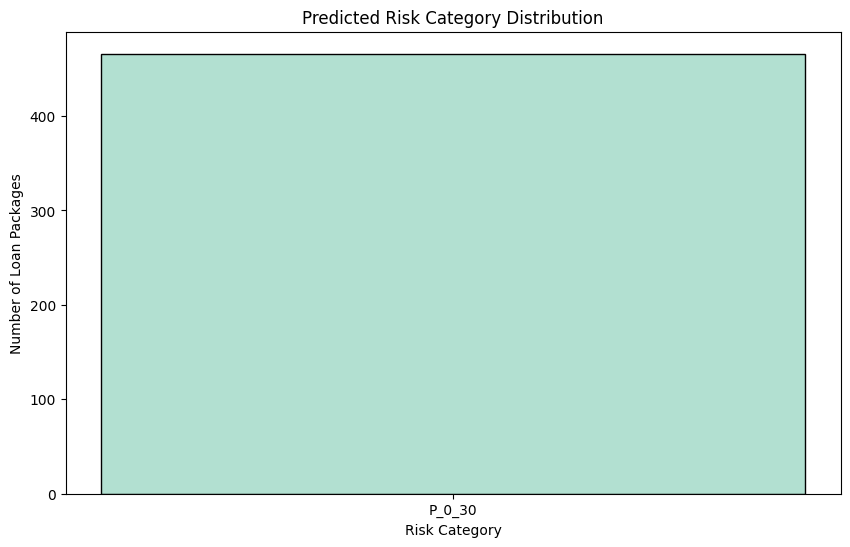

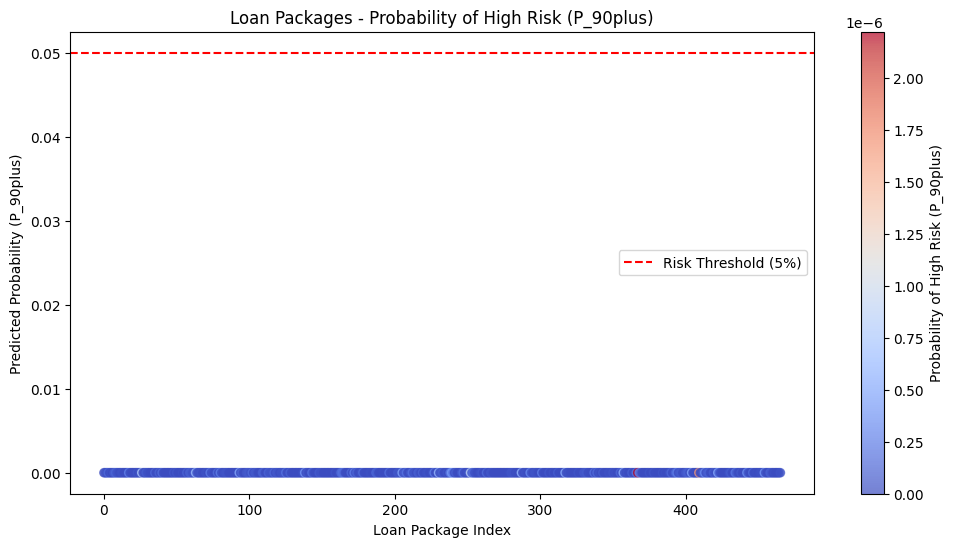

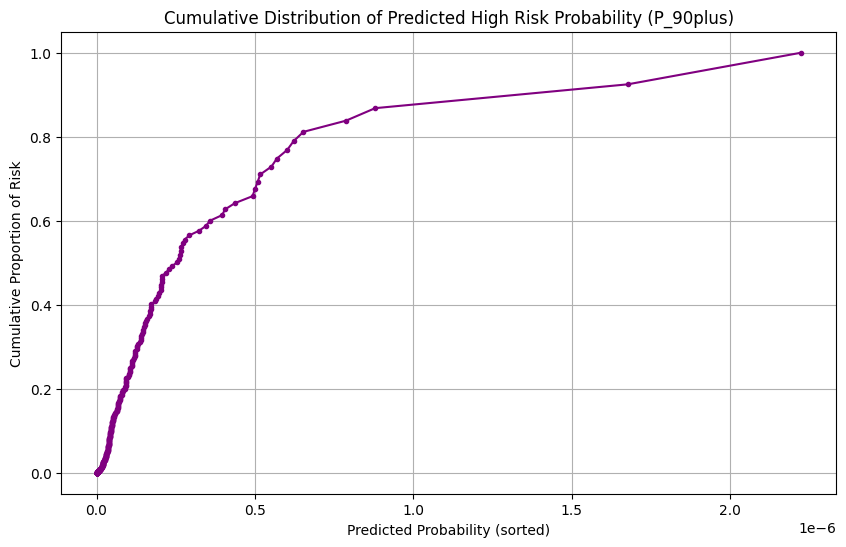

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 假设已有数据
target_cols = ['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']
y_true = y_test
y_pred = y_pred_probs

# 数据整合方便绘图
df_true = pd.DataFrame(y_true, columns=[f"{col}_True" for col in target_cols])
df_pred = pd.DataFrame(y_pred, columns=[f"{col}_Pred" for col in target_cols])
df_combined = pd.concat([df_true, df_pred], axis=1)

# 为每个贷款包确定主导风险类别（以预测概率为准）
df_combined['Predicted_Max_Category'] = np.argmax(y_pred, axis=1)
risk_labels = np.array(target_cols)
df_combined['Predicted_Max_Label'] = risk_labels[df_combined['Predicted_Max_Category']]

# （一）风险概率分布直方图
plt.figure(figsize=(10, 6))
sns.histplot(data=df_combined, x='Predicted_Max_Label', hue='Predicted_Max_Label', shrink=0.8, palette='Set2', legend=False)
plt.title('Predicted Risk Category Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Number of Loan Packages')
plt.show()

# （二）风险散点图（以P_90plus概率为风险严重性指标）
plt.figure(figsize=(12, 6))
scatter = plt.scatter(range(len(y_pred)), y_pred[:, 3], c=y_pred[:, 3], cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Probability of High Risk (P_90plus)')
plt.title('Loan Packages - Probability of High Risk (P_90plus)')
plt.xlabel('Loan Package Index')
plt.ylabel('Predicted Probability (P_90plus)')
plt.axhline(y=0.05, color='r', linestyle='--', label='Risk Threshold (5%)')
plt.legend()
plt.show()

# （三）累计风险概率曲线 (以P_90plus为例)
sorted_risk = np.sort(y_pred[:, 3])
cumulative_risk = np.cumsum(sorted_risk) / np.sum(sorted_risk)

plt.figure(figsize=(10, 6))
plt.plot(sorted_risk, cumulative_risk, marker='.', linestyle='-', color='purple')
plt.title('Cumulative Distribution of Predicted High Risk Probability (P_90plus)')
plt.xlabel('Predicted Probability (sorted)')
plt.ylabel('Cumulative Proportion of Risk')
plt.grid(True)
plt.show()


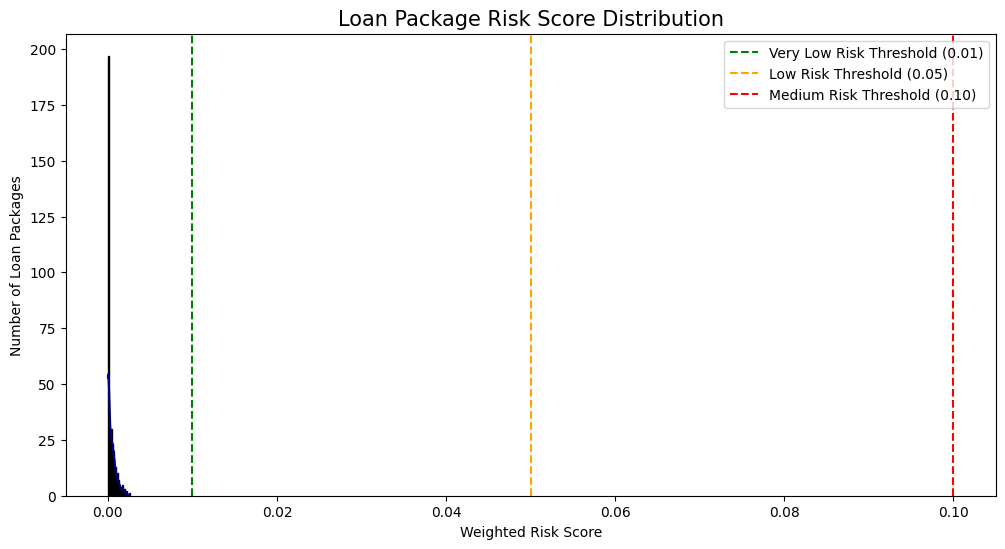

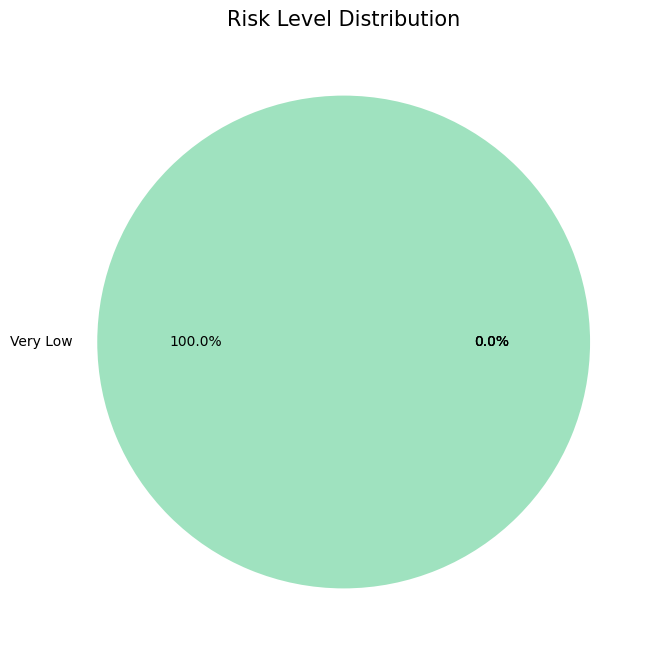

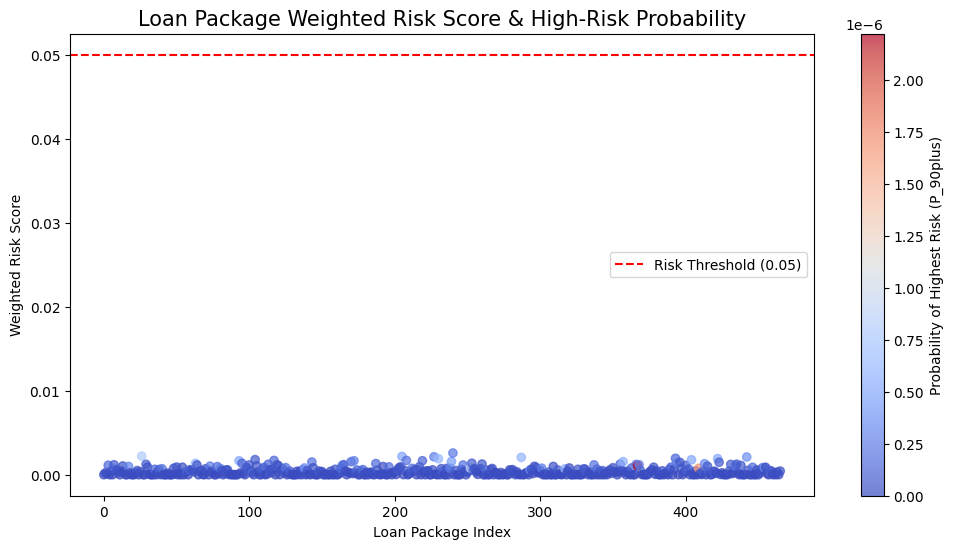

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 已有数据
target_cols = ['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']
y_true = y_test
y_pred = y_pred_probs

# 计算综合风险得分（权重根据实际需求调整）
risk_weights = np.array([0, 0.3, 0.6, 1])
risk_scores = np.dot(y_pred, risk_weights)

# 将风险得分合并到数据框
df_risk_scores = pd.DataFrame({
    'Risk_Score': risk_scores,
    'High_Risk_Prob': y_pred[:, 3]  # 单独记录最高风险概率
})

# 根据风险得分确定风险等级
df_risk_scores['Risk_Level'] = pd.cut(df_risk_scores['Risk_Score'],
                                      bins=[-np.inf, 0.01, 0.05, 0.1, np.inf],
                                      labels=['Very Low', 'Low', 'Medium', 'High'])

# (一) 风险得分直方图（体现风险差异）
plt.figure(figsize=(12, 6))
sns.histplot(df_risk_scores['Risk_Score'], bins=30, kde=True, color='navy')
plt.title('Loan Package Risk Score Distribution', fontsize=15)
plt.xlabel('Weighted Risk Score')
plt.ylabel('Number of Loan Packages')
plt.axvline(x=0.01, color='green', linestyle='--', label='Very Low Risk Threshold (0.01)')
plt.axvline(x=0.05, color='orange', linestyle='--', label='Low Risk Threshold (0.05)')
plt.axvline(x=0.1, color='red', linestyle='--', label='Medium Risk Threshold (0.10)')
plt.legend()
plt.show()

# (二) 风险等级占比饼图（清晰区分风险类别）
plt.figure(figsize=(8, 8))
df_risk_scores['Risk_Level'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#9FE2BF','#FFDDC1','#FFABAB','#FF6961'])
plt.title('Risk Level Distribution', fontsize=15)
plt.ylabel('')
plt.show()

# (三) 风险得分与最高风险概率散点图（明确定价决策）
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_risk_scores.index, df_risk_scores['Risk_Score'],
                      c=df_risk_scores['High_Risk_Prob'], cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Probability of Highest Risk (P_90plus)')
plt.axhline(y=0.05, color='red', linestyle='--', label='Risk Threshold (0.05)')
plt.title('Loan Package Weighted Risk Score & High-Risk Probability', fontsize=15)
plt.xlabel('Loan Package Index')
plt.ylabel('Weighted Risk Score')
plt.legend()
plt.show()


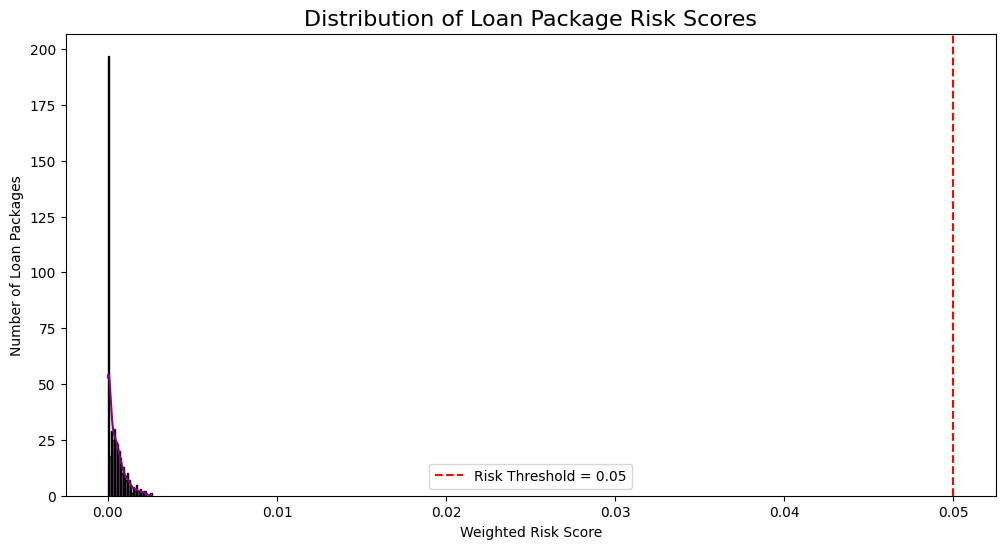

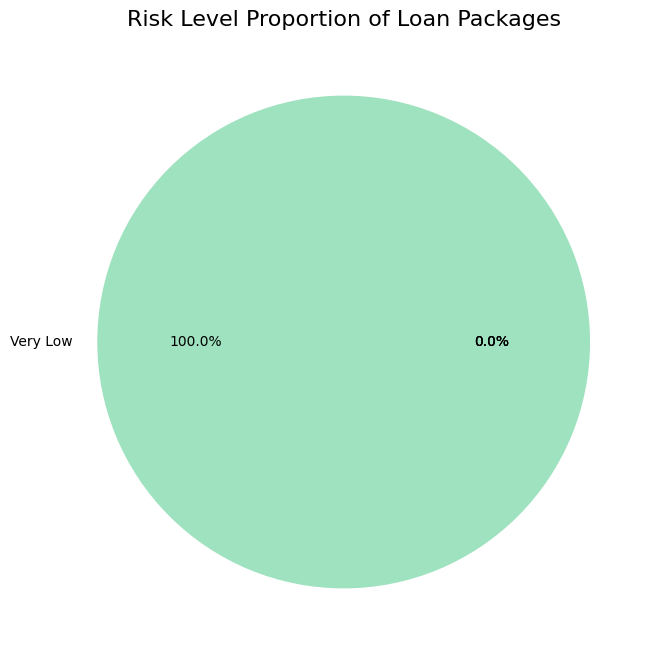

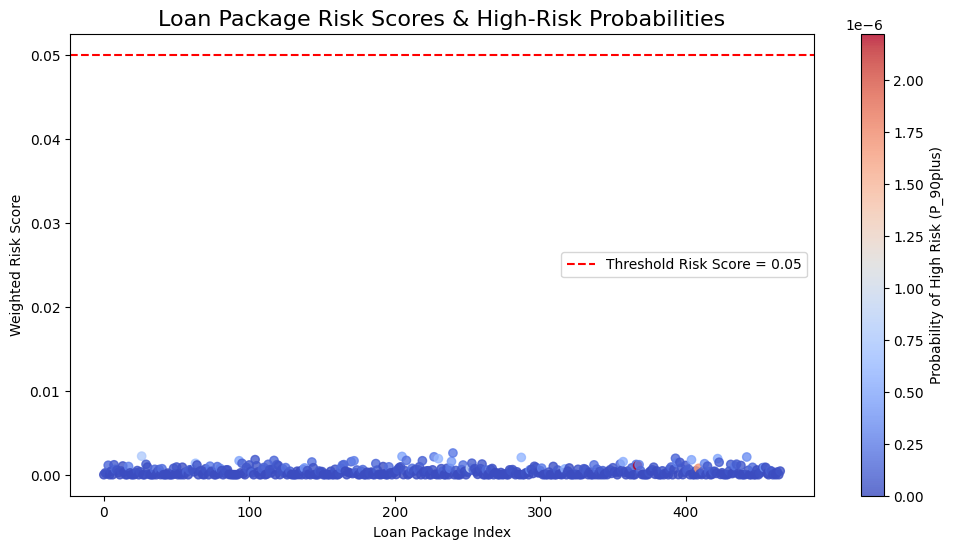

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 已有的数据
target_cols = ['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']
risk_weights = np.array([0, 0.3, 0.6, 1.0])

# 计算风险得分（权重越高风险越大）
risk_scores = np.dot(y_pred_probs, risk_weights)

# 创建包含真实数据和预测风险得分的数据框
df_results = pd.DataFrame({
    'Risk_Score': risk_scores,
    'High_Risk_Probability': y_pred_probs[:, 3],  # P_90plus概率
    'P_0_30': y_pred_probs[:, 0],
    'P_31_60': y_pred_probs[:, 1],
    'P_61_90': y_pred_probs[:, 2],
    'P_90plus': y_pred_probs[:, 3]
})

plt.figure(figsize=(12, 6))
sns.histplot(df_results['Risk_Score'], bins=30, kde=True, color='purple')
plt.title('Distribution of Loan Package Risk Scores', fontsize=16)
plt.xlabel('Weighted Risk Score')
plt.ylabel('Number of Loan Packages')
plt.axvline(x=0.05, color='red', linestyle='--', label='Risk Threshold = 0.05')
plt.legend()
plt.show()

df_results['Risk_Level'] = pd.cut(df_results['Risk_Score'],
                                  bins=[-np.inf, 0.01, 0.05, 0.1, np.inf],
                                  labels=['Very Low', 'Low', 'Medium', 'High'])

plt.figure(figsize=(8, 8))
df_results['Risk_Level'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#9FE2BF','#FFDDC1','#FFABAB','#FF6961']
)
plt.title('Risk Level Proportion of Loan Packages', fontsize=16)
plt.ylabel('')
plt.show()

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_results.index, df_results['Risk_Score'],
                      c=df_results['High_Risk_Probability'], cmap='coolwarm', alpha=0.8)

plt.colorbar(scatter, label='Probability of High Risk (P_90plus)')
plt.axhline(y=0.05, color='red', linestyle='--', label='Threshold Risk Score = 0.05')

plt.title('Loan Package Risk Scores & High-Risk Probabilities', fontsize=16)
plt.xlabel('Loan Package Index')
plt.ylabel('Weighted Risk Score')
plt.legend()
plt.show()


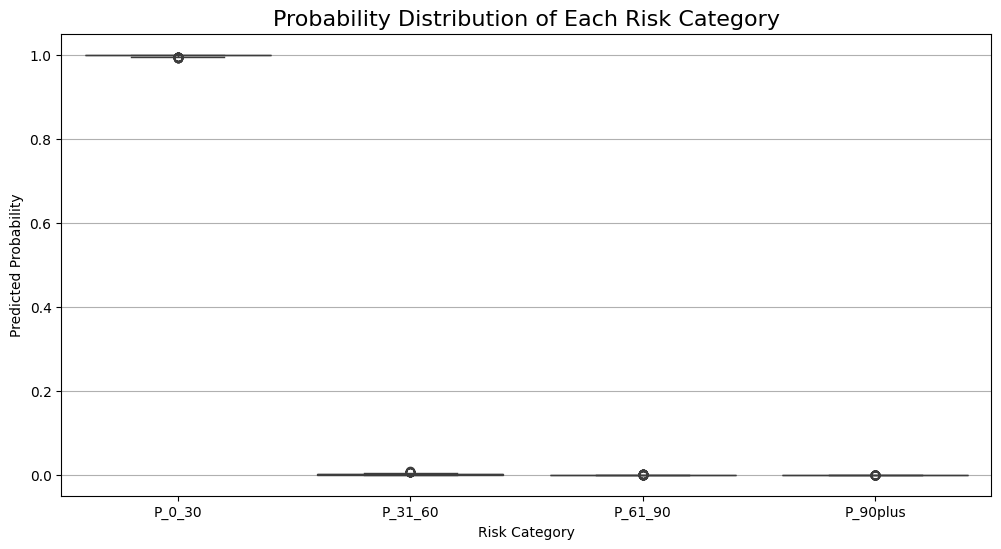

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_results[['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']])
plt.title('Probability Distribution of Each Risk Category', fontsize=16)
plt.ylabel('Predicted Probability')
plt.xlabel('Risk Category')
plt.grid(True, axis='y')
plt.show()


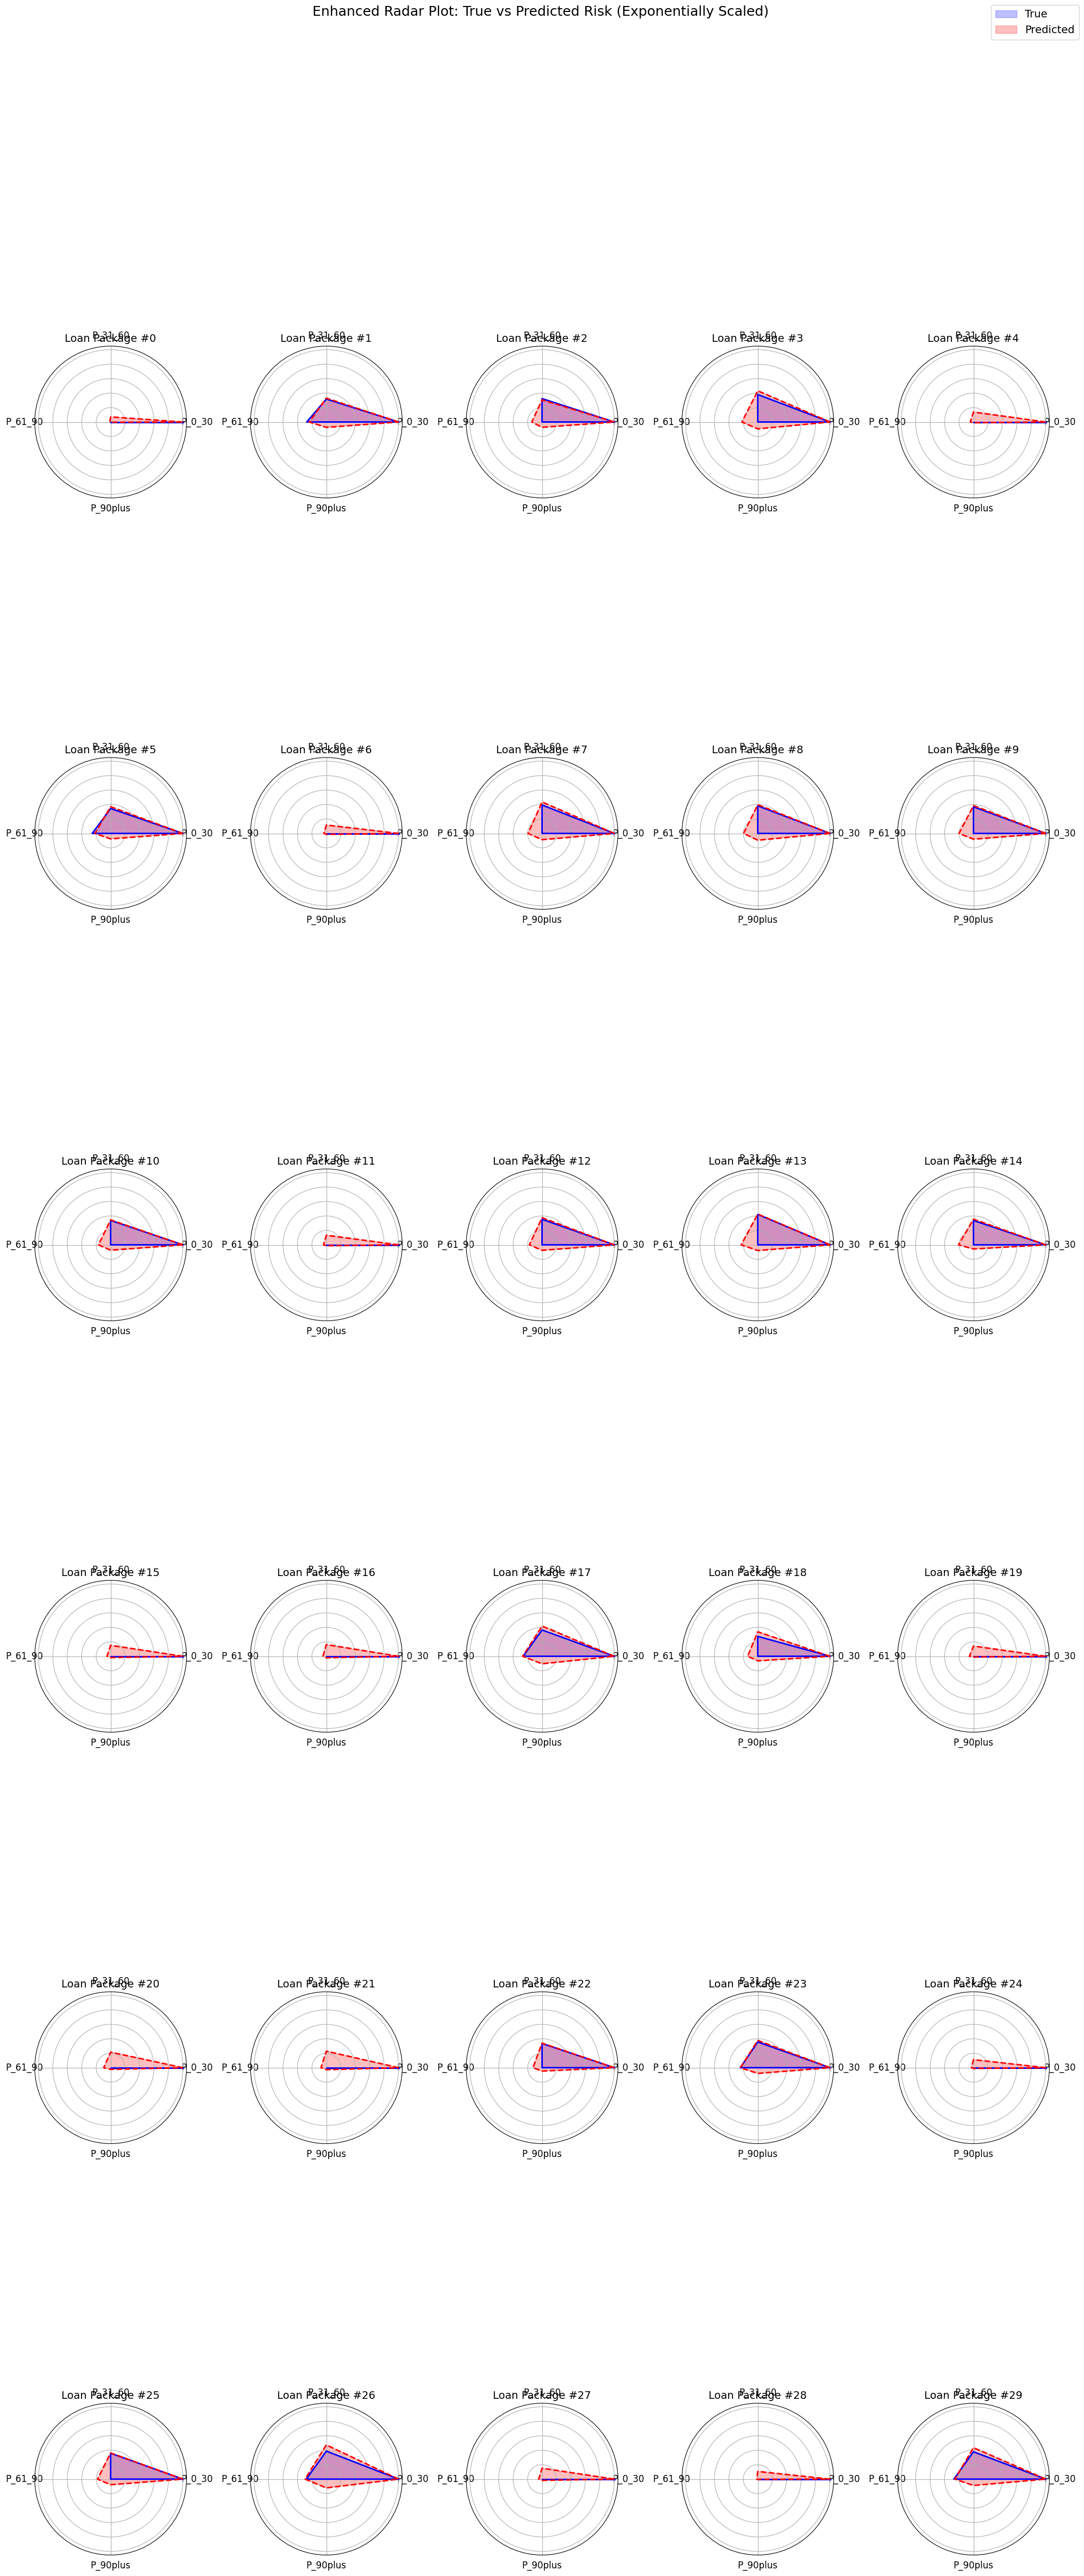

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 选择展示的样本数量
num_samples = 30
y_true_samples = y_test[:num_samples]
y_pred_samples = y_pred_probs[:num_samples]

labels = ['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']
num_vars = len(labels)

# 自定义指数缩放函数，更明显地拉开数值差距
def exp_scale(probs, exp_factor=0.15):
    return np.power(probs, exp_factor)

# 应用指数缩放
y_true_scaled = exp_scale(y_true_samples)
y_pred_scaled = exp_scale(y_pred_samples)

# 创建雷达图
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合雷达图

fig, axes = plt.subplots(figsize=(20, 48), nrows=6, ncols=5, subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx in range(num_samples):
    ax = axes[idx]

    # 真实值与预测值的雷达图坐标
    values_true = y_true_scaled[idx].tolist()
    values_true += values_true[:1]  # 闭合图形

    values_pred = y_pred_scaled[idx].tolist()
    values_pred += values_pred[:1]  # 闭合图形

    # 绘制真实值
    ax.fill(angles, values_true, color='blue', alpha=0.25, label='True')
    ax.plot(angles, values_true, color='blue', linewidth=2)

    # 绘制预测值
    ax.fill(angles, values_pred, color='red', alpha=0.25, label='Predicted')
    ax.plot(angles, values_pred, color='red', linewidth=2, linestyle='--')

    # 设置雷达图的轴标签
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels([])  # 隐藏Y轴刻度
    ax.set_title(f'Loan Package #{idx}', size=14)

# 统一图例放置在最右上角
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=14)

plt.suptitle('Enhanced Radar Plot: True vs Predicted Risk (Exponentially Scaled)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()


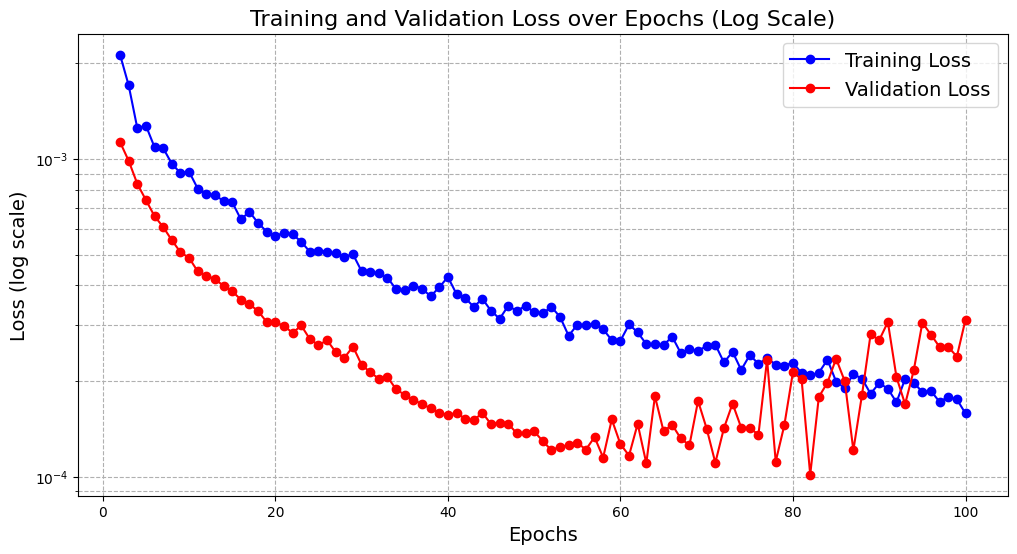

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 从第二个epoch开始取数据，跳过第一个epoch
loss = history.history['loss'][1:]
val_loss = history.history['val_loss'][1:]

# 重新定义epoch范围（从第2个epoch开始）
epochs = range(2, len(loss) + 2)

plt.figure(figsize=(12, 6))

# 使用对数尺度缩放，更好地显示细微差别
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')

plt.yscale('log')  # 对数尺度缩放Y轴，更好体现细节

plt.title('Training and Validation Loss over Epochs (Log Scale)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (log scale)', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, which="both", ls="--")

plt.show()


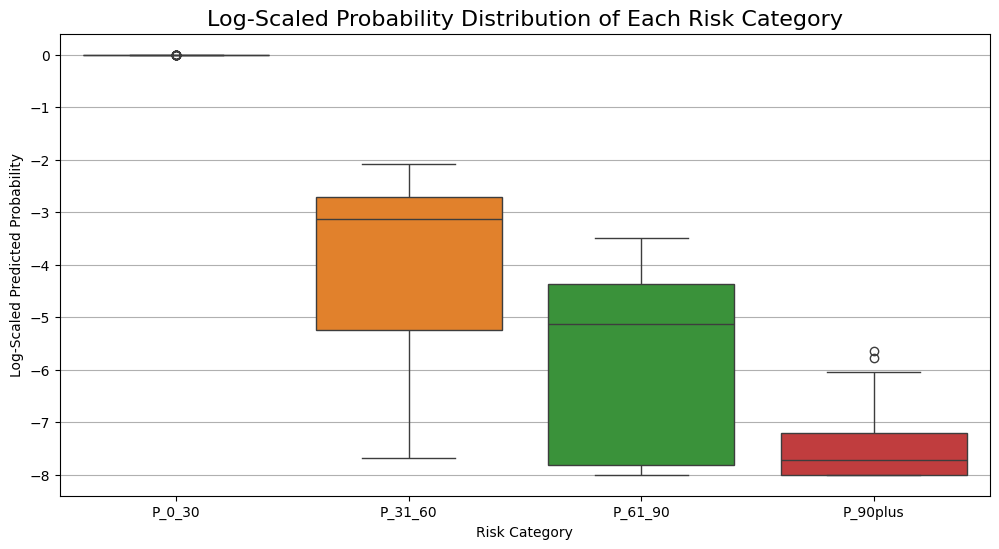

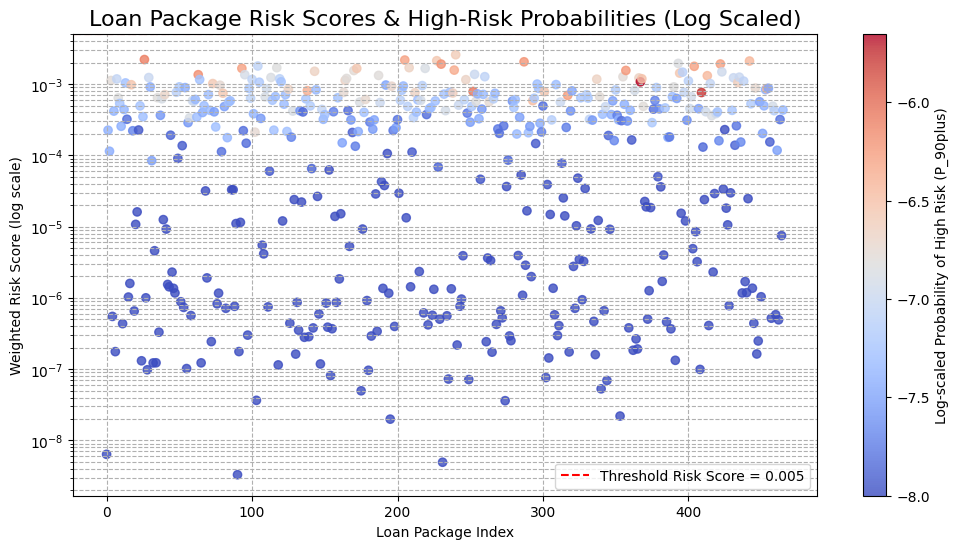

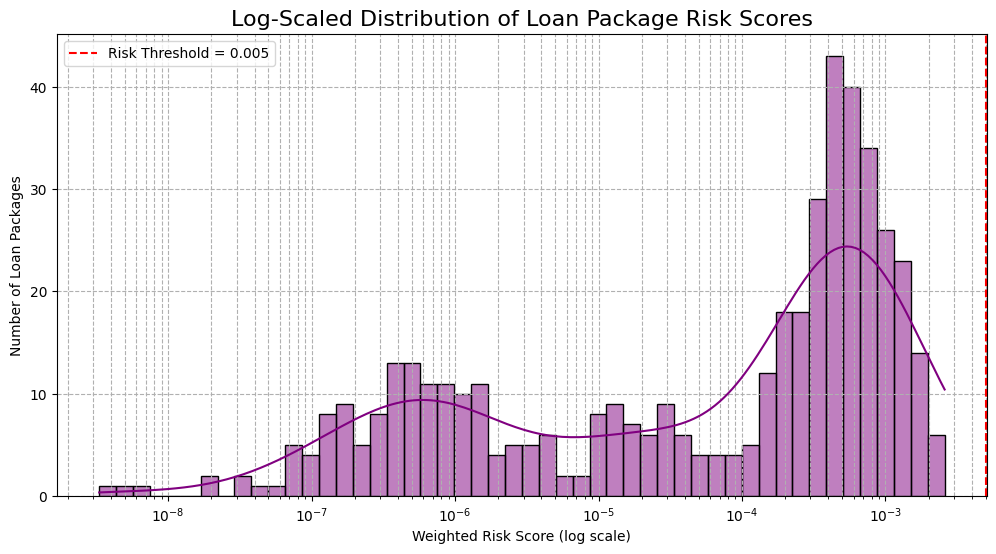

In [ ]:
plt.figure(figsize=(12, 6))

# 取对数(添加极小值避免对数0问题)
log_data = np.log10(df_results[['P_0_30', 'P_31_60', 'P_61_90', 'P_90plus']] + 1e-8)

sns.boxplot(data=log_data)
plt.title('Log-Scaled Probability Distribution of Each Risk Category', fontsize=16)
plt.ylabel('Log-Scaled Predicted Probability')
plt.xlabel('Risk Category')
plt.grid(True, axis='y')

plt.show()

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_results.index, df_results['Risk_Score'],
                      c=np.log10(df_results['High_Risk_Probability'] + 1e-8),
                      cmap='coolwarm', alpha=0.8)

plt.colorbar(scatter, label='Log-scaled Probability of High Risk (P_90plus)')
plt.yscale('log')  # 对数尺度展示风险得分
plt.axhline(y=0.005, color='red', linestyle='--', label='Threshold Risk Score = 0.005')

plt.title('Loan Package Risk Scores & High-Risk Probabilities (Log Scaled)', fontsize=16)
plt.xlabel('Loan Package Index')
plt.ylabel('Weighted Risk Score (log scale)')
plt.legend()
plt.grid(True, which="both", ls="--")

plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df_results['Risk_Score'], bins=50, kde=True, color='purple', log_scale=True)

plt.axvline(x=0.005, color='red', linestyle='--', label='Risk Threshold = 0.005')
plt.title('Log-Scaled Distribution of Loan Package Risk Scores', fontsize=16)
plt.xlabel('Weighted Risk Score (log scale)')
plt.ylabel('Number of Loan Packages')
plt.legend()
plt.grid(True, which="both", ls="--")

plt.show()
